# Decision 2 — Secured Loan Underwriting under Vendor Uncertainty

This notebook implements **Stylised Decision 2**: how vendor disagreement on flood damage ratios
translates into materially different underwriting outcomes for secured loans.

**Transmission chain:**

```
d_iv  (vendor damage ratio for property i, vendor v)
  → V_iv  = V_i0 × (1 − κ × d_iv)          collateral value after flood damage
  → LTV_iv = Loan_i / V_iv                   stressed loan-to-value ratio
  → Lending outcome:  LTV ≤ LTV₁  → Standard terms
                      LTV₁ < LTV ≤ LTV₂  → Tighter terms / additional pricing
                      LTV > LTV₂  → Reject / additional collateral required
```

**κ** (kappa) controls the fraction of the damage ratio that passes through to collateral value.
κ = 1 → full passthrough; κ = 0.5 → partial (e.g. insurance, resilience measures).

Unlike Decision 1 (credit loss provisioning), the key outcome here is **binary lending decisions**
driven by LTV thresholds — small vendor differences can tip a loan from approved to rejected.


In [1]:
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
from scipy import stats
from pathlib import Path

# ── Colour palette (consistent with other notebooks) ──────────────────────
BLUE  = '#2166ac'
RED   = '#d6604d'
AMBER = '#f4a582'
GREEN = '#4dac26'
GREY  = '#878787'
TEAL  = '#5ab4ac'

DATA_PATH = '../../data/raw/cfrf_garp_defended_flood.csv'

print("Imports OK")

Imports OK


## Step 1 — Parameters
Edit this cell to explore different scenarios.

In [2]:
# =============================================================================
# PARAMETERS — edit this cell to explore different scenarios
# =============================================================================

# --- Vendor selection ---
VENDOR_SEED    = 1     # integer ≥ 0 — simulates consulting a different vendor
PORTFOLIO_SEED = 42    # controls loan characteristics — keep fixed to compare vendors

# --- Flood hazard ---
RETURN_PERIOD = 200    # years (CFRF/GARP data is for the 1-in-200 year event)
#   Annual exceedance probability = 1 / RETURN_PERIOD = 0.5%

# --- Probability framing ---
# "conditional"   — flood is certain (p = 1); isolates vendor disagreement cleanly
# "unconditional" — probability-weighted; d_eff = p_annual × d_vendor
FRAMING = "conditional"

# --- Damage-to-collateral passthrough ---
# V_iv = V_i0 × (1 − κ × d_iv)
# κ = 1.0 → full passthrough (value falls by the full damage ratio)
# κ < 1.0 → partial passthrough (insurance, resilience, partial repair)
KAPPA = 1.0

# --- Baseline property value ---
# Toggle between a fixed value (simpler) and lognormal draws (more realistic)
V0_FIXED        = True     # True → all loans share V0_FIXED_VALUE
V0_FIXED_VALUE  = 100.0    # baseline property value (£, £k, or £m — units consistent)
V0_LN_MU        = 4.605    # log(100) — lognormal median ≈ 100 when V0_FIXED=False
V0_LN_SIGMA     = 0.40     # moderate spread; P10≈67, P90≈150

# --- LTV at origination (bucket assignment) ---
LTV_BUCKETS = [0.60, 0.75, 0.85]    # discrete LTV levels at origination
LTV_WEIGHTS = [1/3,  1/3,  1/3]     # probability of each bucket (must sum to 1)
#   To up-weight lower-LTV loans: e.g. [0.50, 0.30, 0.20]

# --- Lending thresholds ---
LTV_THRESHOLD_1 = 0.80    # LTV ≤ this → standard terms
LTV_THRESHOLD_2 = 0.90    # LTV ≤ this → tighter terms; above → reject

# --- Portfolio size ---
N_LOANS = 100

## Step 2 — Load CFRF/GARP Data and Sample Vendor Damage Ratios

In [3]:
df = pd.read_csv(DATA_PATH)
df.rename(columns={'minimim_dr': 'minimum_dr'}, inplace=True)
df = df.dropna(subset=['property_rank']).reset_index(drop=True)
df['property_rank'] = df['property_rank'].astype(int)
n_props = len(df)  # should be 100

# --- Triangular distribution parameters for each property ---
tri_a = df['minimum_dr'].values.astype(float)   # support lower bound
tri_b = df['maximum_dr'].values.astype(float)   # support upper bound
tri_c = np.clip(3.0 * df['mean_dr'].values - tri_a - tri_b, tri_a, tri_b)  # mode

damage_summary = pd.DataFrame({
    'property_rank': df['property_rank'],
    'd_min':  tri_a,
    'd_mean': df['mean_dr'].values,
    'd_max':  tri_b,
    'd_mode': tri_c,
})

# --- Vendor sampling: inverse-CDF draw from Triangular(a, c, b) ---
def triangular_sample(rng, a, b, c):
    u    = rng.uniform(size=len(a))
    span = np.where(b > a, b - a, 1.0)
    fc   = np.where(b > a, (c - a) / span, 0.0)
    left  = a + np.sqrt(np.maximum(u, 0) * span * np.maximum(c - a, 0))
    right = b - np.sqrt(np.maximum(1 - u, 0) * span * np.maximum(b - c, 0))
    x     = np.where(u <= fc, left, right)
    return np.where(b > a, np.clip(x, 0, 1), a)   # point mass if b == a

vendor_rng = np.random.default_rng(VENDOR_SEED)
d_vendor   = triangular_sample(vendor_rng, tri_a, tri_b, tri_c)
damage_summary['d_vendor'] = d_vendor

print(f"Loaded {n_props} properties from CFRF/GARP benchmarking study.")
print(f"Vendor draw (seed={VENDOR_SEED}):")
print(f"  Mean d = {d_vendor.mean():.4f}  |  Max d = {d_vendor.max():.4f}")
print(f"  Properties with d > 0:   {(d_vendor > 0).sum()}")
print(f"  Properties with d > 0.1: {(d_vendor > 0.1).sum()}")

Loaded 100 properties from CFRF/GARP benchmarking study.
Vendor draw (seed=1):
  Mean d = 0.1400  |  Max d = 0.8331
  Properties with d > 0:   80
  Properties with d > 0.1: 45


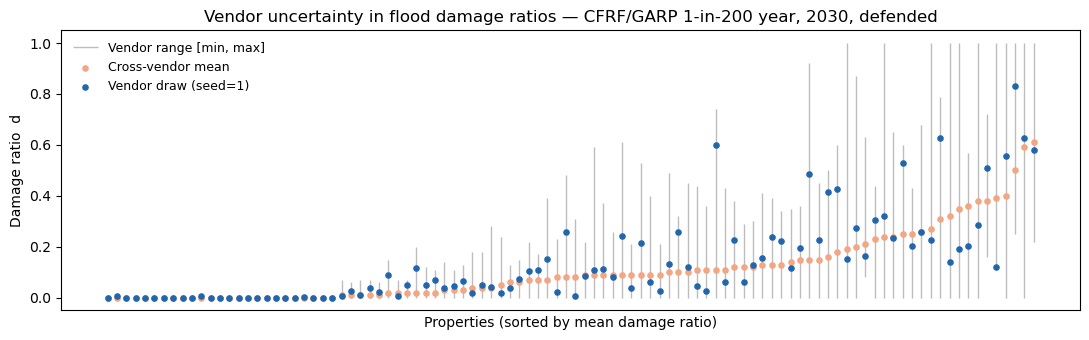

In [4]:
idx_mean = np.argsort(damage_summary['d_mean'].values)
x_pos = np.arange(n_props)

fig, ax = plt.subplots(figsize=(11, 3.5))
ax.vlines(x_pos,
          damage_summary['d_min'].values[idx_mean],
          damage_summary['d_max'].values[idx_mean],
          color=GREY, linewidth=1.0, alpha=0.55, label='Vendor range [min, max]')
ax.scatter(x_pos, damage_summary['d_mean'].values[idx_mean],
           color=AMBER, s=14, zorder=3, label='Cross-vendor mean')
ax.scatter(x_pos, damage_summary['d_vendor'].values[idx_mean],
           color=BLUE, s=14, zorder=3, label=f'Vendor draw (seed={VENDOR_SEED})')

ax.set_xlabel('Properties (sorted by mean damage ratio)')
ax.set_ylabel('Damage ratio  d')
ax.set_title('Vendor uncertainty in flood damage ratios — CFRF/GARP 1-in-200 year, 2030, defended')
ax.set_xticks([])
ax.legend(frameon=False, fontsize=9)
plt.tight_layout()
plt.savefig('../../outputs/figures/decision2/02_vendor_damage_ratios.png', dpi=300, bbox_inches='tight')
plt.show()

## Step 3 — Construct Loan Portfolio

In [5]:
Path('../../outputs/figures/decision2').mkdir(parents=True, exist_ok=True)

port_rng = np.random.default_rng(PORTFOLIO_SEED)

# --- Baseline property value ---
if V0_FIXED:
    v0 = np.full(N_LOANS, V0_FIXED_VALUE)
else:
    v0 = stats.lognorm.rvs(
        s=V0_LN_SIGMA,
        scale=np.exp(V0_LN_MU),
        size=N_LOANS,
        random_state=int(port_rng.integers(2**31))
    )

# --- LTV bucket assignment ---
ltv_weights_norm = np.array(LTV_WEIGHTS) / np.sum(LTV_WEIGHTS)
ltv_0 = port_rng.choice(LTV_BUCKETS, size=N_LOANS, p=ltv_weights_norm)

# --- Loan amount: Loan_i = LTV_i0 × V_i0 ---
loan = ltv_0 * v0

portfolio = pd.DataFrame({
    'property_rank': df['property_rank'],
    'v0':            v0,
    'ltv0':          ltv_0,
    'loan':          loan,
})

print(f"Portfolio constructed: {N_LOANS} loans")
print(f"Property value:  {'fixed V₀ = ' + str(V0_FIXED_VALUE) if V0_FIXED else 'lognormal (μ=' + str(V0_LN_MU) + ', σ=' + str(V0_LN_SIGMA) + ')'}")
print(f"Loan amount:     mean = {loan.mean():.1f}  |  total = {loan.sum():.1f}")
print()
print(f"LTV bucket assignment:")
for b, w in zip(LTV_BUCKETS, ltv_weights_norm):
    n_b = (ltv_0 == b).sum()
    print(f"  LTV₀ = {b:.0%}  (weight {w:.2f})  →  {n_b} loans")

Portfolio constructed: 100 loans
Property value:  fixed V₀ = 100.0
Loan amount:     mean = 73.3  |  total = 7335.0

LTV bucket assignment:
  LTV₀ = 60%  (weight 0.33)  →  33 loans
  LTV₀ = 75%  (weight 0.33)  →  34 loans
  LTV₀ = 85%  (weight 0.33)  →  33 loans


NameError: name 'V0_FxXED_VALUE' is not defined

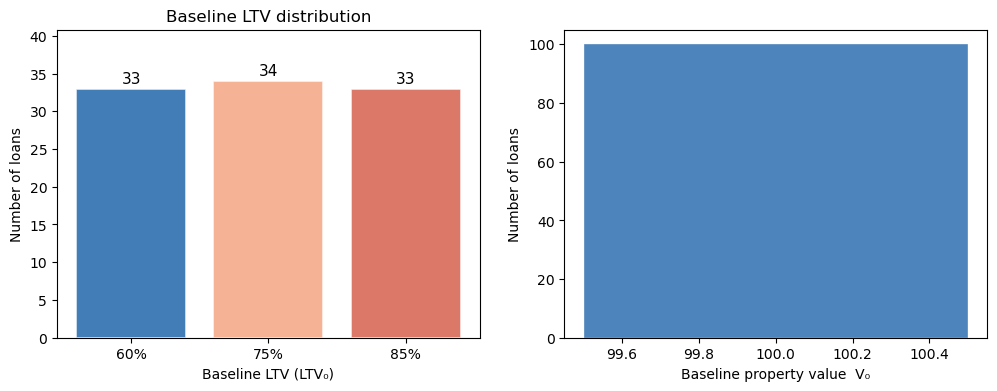

In [8]:
bucket_colours = [BLUE, AMBER, RED]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# LTV bucket counts
ax = axes[0]
counts = [(ltv_0 == b).sum() for b in LTV_BUCKETS]
bars = ax.bar([f'{b:.0%}' for b in LTV_BUCKETS], counts,
              color=bucket_colours, alpha=0.85, edgecolor='white', linewidth=1.2)
for bar, c in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width()/2, c + 0.3, str(c),
            ha='center', va='bottom', fontsize=11)
ax.set_xlabel('Baseline LTV (LTV₀)')
ax.set_ylabel('Number of loans')
ax.set_title('Baseline LTV distribution')
ax.set_ylim(0, max(counts) * 1.2)

# Property value distribution
ax = axes[1]
ax.hist(v0, bins=20 if not V0_FIXED else 1,
        color=BLUE, alpha=0.8, edgecolor='white', linewidth=0.3)
ax.set_xlabel('Baseline property value  V₀')
ax.set_ylabel('Number of loans')
ax.set_title(f'Property values{"Fixed V₀ = " + str(int(V0_FxXED_VALUE)) if V0_FIXED else "Lognormal sampling"}')
if V0_FIXED:
    ax.set_xlim(V0_FIXED_VALUE - 10, V0_FIXED_VALUE + 10)

fig.suptitle('Step 3 — Loan portfolio at origination', fontsize=12)
plt.tight_layout()
plt.savefig('../../outputs/figures/decision2/03_portfolio_baseline.png', dpi=300, bbox_inches='tight')
plt.show()

## Step 4 — Transmit Damage to Collateral Value and Stressed LTV

In [9]:
p_annual = 1.0 / RETURN_PERIOD

# --- Effective damage under chosen framing ---
if FRAMING == 'conditional':
    d_eff = d_vendor
    framing_label = 'Conditional (flood certain,  p = 1)'
elif FRAMING == 'unconditional':
    d_eff = p_annual * d_vendor
    framing_label = f'Unconditional (RP{RETURN_PERIOD},  p = {p_annual:.4f})'
else:
    raise ValueError(f"FRAMING must be 'conditional' or 'unconditional', got '{FRAMING}'")

# --- Collateral value after damage: V_iv = V_i0 × (1 − κ × d_eff) ---
v_stressed  = np.maximum(v0 * (1.0 - KAPPA * d_eff), 0.0)

# --- Stressed LTV: LTV_iv = Loan_i / V_iv ---
# Cap at a large finite value for loans with complete collateral loss
ltv_stressed = np.where(v_stressed > 0, loan / v_stressed, 9.99)

portfolio['d_vendor']     = d_vendor
portfolio['d_eff']        = d_eff
portfolio['v_stressed']   = v_stressed
portfolio['ltv_stressed'] = ltv_stressed
portfolio['delta_v']      = v_stressed - v0
portfolio['delta_ltv']    = ltv_stressed - ltv_0

print(f"Framing:  {framing_label}")
print(f"κ (damage passthrough) = {KAPPA}")
print()
print(f"{'':30s}  {'Baseline':>10}  {'Stressed':>10}  {'Change':>10}")
print("-" * 65)
print(f"{'Mean property value':30s}  {v0.mean():>10.2f}  {v_stressed.mean():>10.2f}  {(v_stressed - v0).mean():>+10.2f}")
print(f"{'Mean LTV':30s}  {ltv_0.mean():>10.4f}  {ltv_stressed.mean():>10.4f}  {(ltv_stressed - ltv_0).mean():>+10.4f}")
print(f"{'Loans with LTV increase':30s}  {'':>10}  {(ltv_stressed > ltv_0).sum():>10d}")

Framing:  Conditional (flood certain,  p = 1)
κ (damage passthrough) = 1.0

                                  Baseline    Stressed      Change
-----------------------------------------------------------------
Mean property value                 100.00       86.00      -14.00
Mean LTV                            0.7335      0.9394     +0.2059
Loans with LTV increase                             80


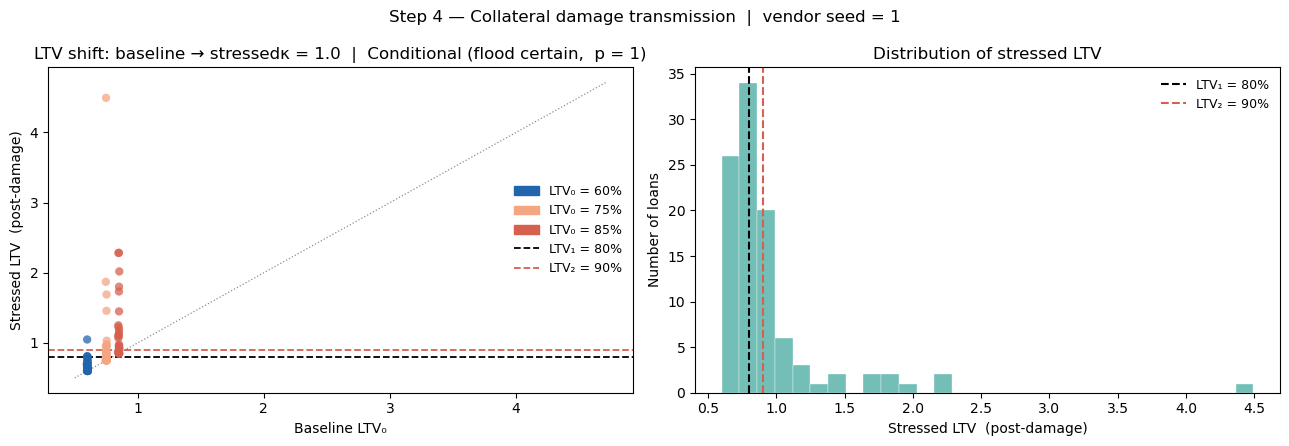

In [11]:
_jitter_rng = np.random.default_rng(0)
_jitter      = _jitter_rng.uniform(-0.004, 0.004, N_LOANS)

# Map each loan to its bucket colour
ltv_colours = np.array([bucket_colours[LTV_BUCKETS.index(l)] for l in ltv_0])

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Scatter: LTV₀ vs LTV_stressed
ax = axes[0]
ax.scatter(ltv_0 + _jitter, ltv_stressed,
           c=ltv_colours, alpha=0.75, s=36, edgecolors='none', zorder=3)
ax.axhline(LTV_THRESHOLD_1, color='black', lw=1.3, ls='--',
           label=f'LTV₁ = {LTV_THRESHOLD_1:.0%} (tighter terms)')
ax.axhline(LTV_THRESHOLD_2, color=RED,     lw=1.3, ls='--',
           label=f'LTV₂ = {LTV_THRESHOLD_2:.0%} (reject)')
lim = max(ltv_stressed.max(), ltv_0.max()) * 1.05
ax.plot([0.5, lim], [0.5, lim], 'k:', lw=0.9, alpha=0.45)
ax.set_xlabel('Baseline LTV₀')
ax.set_ylabel('Stressed LTV  (post-damage)')
ax.set_title(f'LTV shift: baseline → stressedκ = {KAPPA}  |  {framing_label}')
bucket_handles = [mpatches.Patch(color=bucket_colours[j], label=f'LTV₀ = {b:.0%}')
                  for j, b in enumerate(LTV_BUCKETS)]
thresh_handles = [
    plt.Line2D([0], [0], color='black', lw=1.3, ls='--', label=f'LTV₁ = {LTV_THRESHOLD_1:.0%}'),
    plt.Line2D([0], [0], color=RED,     lw=1.3, ls='--', label=f'LTV₂ = {LTV_THRESHOLD_2:.0%}'),
]
ax.legend(handles=bucket_handles + thresh_handles, frameon=False, fontsize=9)

# Histogram of stressed LTV
ax = axes[1]
ax.hist(ltv_stressed, bins=30, color=TEAL, alpha=0.85, edgecolor='white', linewidth=0.3)
ax.axvline(LTV_THRESHOLD_1, color='black', lw=1.5, ls='--',
           label=f'LTV₁ = {LTV_THRESHOLD_1:.0%}')
ax.axvline(LTV_THRESHOLD_2, color=RED,     lw=1.5, ls='--',
           label=f'LTV₂ = {LTV_THRESHOLD_2:.0%}')
ax.set_xlabel('Stressed LTV  (post-damage)')
ax.set_ylabel('Number of loans')
ax.set_title('Distribution of stressed LTV')
ax.legend(frameon=False, fontsize=9)

fig.suptitle(f'Step 4 — Collateral damage transmission  |  vendor seed = {VENDOR_SEED}',
             fontsize=12)
plt.tight_layout()
plt.savefig('../../outputs/figures/decision2/04_ltv_shift.png', dpi=300, bbox_inches='tight')
plt.show()

## Step 5 — Apply Lending Rules

In [12]:
def classify_ltv(ltv, t1, t2):
    """Map LTV values to lending outcome labels."""
    return np.where(ltv <= t1, 'standard',
           np.where(ltv <= t2, 'tighter', 'reject'))

outcome_base     = classify_ltv(ltv_0,          LTV_THRESHOLD_1, LTV_THRESHOLD_2)
outcome_stressed = classify_ltv(ltv_stressed,    LTV_THRESHOLD_1, LTV_THRESHOLD_2)

portfolio['outcome_base']     = outcome_base
portfolio['outcome_stressed'] = outcome_stressed
portfolio['outcome_changed']  = (outcome_base != outcome_stressed)

cats = ['standard', 'tighter', 'reject']
print(f"{'Outcome':<12}  {'Baseline':>10}  {'Stressed':>10}  {'Δ':>8}")
print("-" * 46)
for cat in cats:
    n_b = (outcome_base == cat).sum()
    n_s = (outcome_stressed == cat).sum()
    print(f"{cat:<12}  {n_b:>10d}  {n_s:>10d}  {n_s - n_b:>+8d}")
print("-" * 46)
print(f"{'Reclassified':<12}  {'':>10}  {portfolio['outcome_changed'].sum():>10d}")

Outcome         Baseline    Stressed         Δ
----------------------------------------------
standard              67          49       -18
tighter               33          21       -12
reject                 0          30       +30
----------------------------------------------
Reclassified                      38


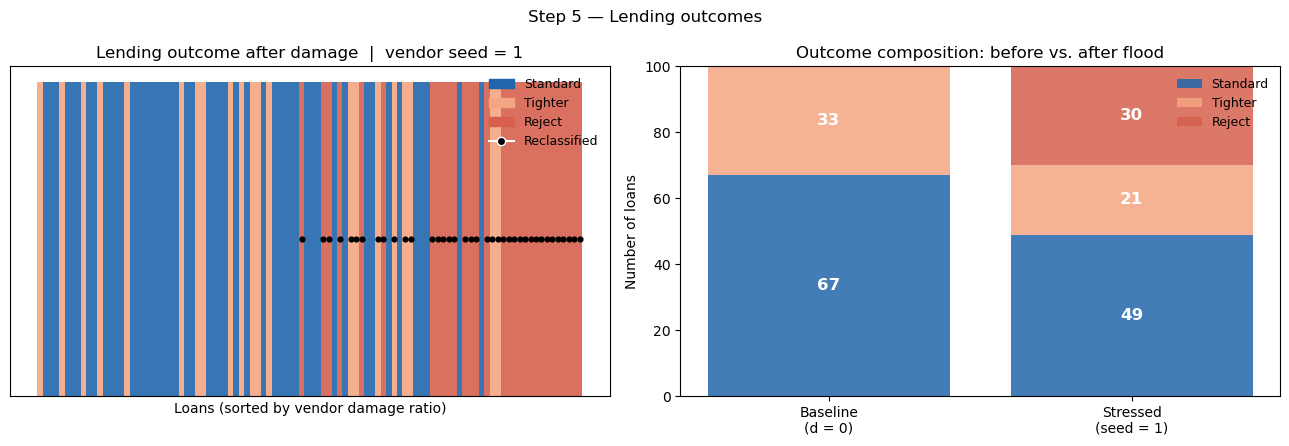

In [13]:
outcome_colours_map = {'standard': BLUE, 'tighter': AMBER, 'reject': RED}
idx_d = np.argsort(d_vendor)   # sort by vendor damage ratio for display

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Per-loan outcome strip (sorted by damage ratio)
ax = axes[0]
bar_colours = [outcome_colours_map[o] for o in outcome_stressed[idx_d]]
ax.bar(np.arange(n_props), np.ones(n_props), color=bar_colours, width=1.0, alpha=0.9)
# Mark loans that changed outcome with a black dot
changed_pos = [pos for pos, i in enumerate(idx_d)
               if portfolio['outcome_changed'].values[i]]
ax.scatter(changed_pos, np.ones(len(changed_pos)) * 0.5,
           color='black', s=12, zorder=4, label='Outcome changed from baseline')
ax.set_xlabel('Loans (sorted by vendor damage ratio)')
ax.set_title(f'Lending outcome after damage  |  vendor seed = {VENDOR_SEED}')
ax.set_yticks([])
ax.set_xticks([])
cat_handles = [mpatches.Patch(color=outcome_colours_map[c], label=c.capitalize())
               for c in cats]
ax.legend(handles=cat_handles + [
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='black',
               markersize=6, label='Reclassified')
], frameon=False, fontsize=9)

# Stacked bar: baseline vs stressed
ax = axes[1]
bottoms_b = 0
bottoms_s = 0
for cat, col in zip(cats, [BLUE, AMBER, RED]):
    val_b = (outcome_base == cat).sum()
    val_s = (outcome_stressed == cat).sum()
    ax.bar([0], [val_b], bottom=[bottoms_b], color=col, alpha=0.85)
    ax.bar([1], [val_s], bottom=[bottoms_s], color=col, alpha=0.85,
           label=cat.capitalize())
    for x, v, b in [(0, val_b, bottoms_b), (1, val_s, bottoms_s)]:
        if v > 0:
            ax.text(x, b + v / 2, str(v), ha='center', va='center',
                    fontsize=12, color='white', fontweight='bold')
    bottoms_b += val_b
    bottoms_s += val_s
ax.set_xticks([0, 1])
ax.set_xticklabels([f'Baseline\n(d = 0)', f'Stressed\n(seed = {VENDOR_SEED})'])
ax.set_ylabel('Number of loans')
ax.set_title('Outcome composition: before vs. after flood')
ax.legend(frameon=False, fontsize=9)

fig.suptitle('Step 5 — Lending outcomes', fontsize=12)
plt.tight_layout()
plt.savefig('../../outputs/figures/decision2/05_outcomes.png', dpi=300, bbox_inches='tight')
plt.show()

## Step 6 — Portfolio Summary Statistics

In [14]:
def portfolio_metrics(outcomes, ltv_arr, v_arr, loan_arr, t1, t2):
    is_standard = outcomes == 'standard'
    is_tighter  = outcomes == 'tighter'
    is_reject   = outcomes == 'reject'
    return {
        'approval_rate':   is_standard.mean(),
        'tighter_rate':    is_tighter.mean(),
        'reject_rate':     is_reject.mean(),
        'mean_ltv':        ltv_arr.mean(),
        'mean_collateral': v_arr.mean(),
        'pct_above_t1':    (ltv_arr > t1).mean(),
        'pct_above_t2':    (ltv_arr > t2).mean(),
    }

m_base = portfolio_metrics(outcome_base,     ltv_0,         v0,         loan, LTV_THRESHOLD_1, LTV_THRESHOLD_2)
m_str  = portfolio_metrics(outcome_stressed, ltv_stressed,  v_stressed, loan, LTV_THRESHOLD_1, LTV_THRESHOLD_2)

rows = [
    ('Approval rate  (LTV ≤ LTV₁)',        f'{m_base["approval_rate"]:.1%}',  f'{m_str["approval_rate"]:.1%}'),
    ('Tighter terms  (LTV₁ < LTV ≤ LTV₂)', f'{m_base["tighter_rate"]:.1%}',   f'{m_str["tighter_rate"]:.1%}'),
    ('Reject rate    (LTV > LTV₂)',         f'{m_base["reject_rate"]:.1%}',    f'{m_str["reject_rate"]:.1%}'),
    ('Mean LTV',                            f'{m_base["mean_ltv"]:.4f}',       f'{m_str["mean_ltv"]:.4f}'),
    ('Mean collateral value',               f'{m_base["mean_collateral"]:.2f}',f'{m_str["mean_collateral"]:.2f}'),
    ('% loans breaching LTV₁',             f'{m_base["pct_above_t1"]:.1%}',   f'{m_str["pct_above_t1"]:.1%}'),
    ('% loans breaching LTV₂',             f'{m_base["pct_above_t2"]:.1%}',   f'{m_str["pct_above_t2"]:.1%}'),
    ('Loans reclassified',                  '—',                               f'{portfolio["outcome_changed"].mean():.1%}'),
]

print(f"{'='*65}")
print(f"PORTFOLIO SUMMARY   {framing_label}")
print(f"κ = {KAPPA}   LTV₁ = {LTV_THRESHOLD_1:.0%}   LTV₂ = {LTV_THRESHOLD_2:.0%}   vendor seed = {VENDOR_SEED}")
print(f"{'='*65}")
print(f"{'Metric':<42}  {'Baseline':>10}  {'Stressed':>10}")
print(f"{'-'*65}")
for label, base, stressed in rows:
    print(f"{label:<42}  {base:>10}  {stressed:>10}")
print(f"{'='*65}")

PORTFOLIO SUMMARY   Conditional (flood certain,  p = 1)
κ = 1.0   LTV₁ = 80%   LTV₂ = 90%   vendor seed = 1
Metric                                        Baseline    Stressed
-----------------------------------------------------------------
Approval rate  (LTV ≤ LTV₁)                      67.0%       49.0%
Tighter terms  (LTV₁ < LTV ≤ LTV₂)               33.0%       21.0%
Reject rate    (LTV > LTV₂)                       0.0%       30.0%
Mean LTV                                        0.7335      0.9394
Mean collateral value                           100.00       86.00
% loans breaching LTV₁                           33.0%       51.0%
% loans breaching LTV₂                            0.0%       30.0%
Loans reclassified                                   —       38.0%


## Step 7 — Vendor Uncertainty Analysis

Fix the portfolio; vary only which vendor is consulted across 1000 draws.

In [15]:
N_VENDOR_DRAWS = 1000

_rng = np.random.default_rng(0)
d_draws = np.stack([
    triangular_sample(_rng, tri_a, tri_b, tri_c)
    for _ in range(N_VENDOR_DRAWS)
])   # shape: (1000, 100)

# Effective damage under framing
if FRAMING == 'conditional':
    d_eff_draws = d_draws
else:
    d_eff_draws = (1.0 / RETURN_PERIOD) * d_draws

# Stressed collateral and LTV — vectorised over all draws at once
v_str_draws   = np.maximum(v0[None, :] * (1.0 - KAPPA * d_eff_draws), 0.0)   # (1000, 100)
ltv_str_draws = np.where(v_str_draws > 0, loan[None, :] / v_str_draws, 9.99)  # (1000, 100)

# Outcome classification for every draw × loan
is_standard_draws = ltv_str_draws <= LTV_THRESHOLD_1
is_tighter_draws  = (ltv_str_draws > LTV_THRESHOLD_1) & (ltv_str_draws <= LTV_THRESHOLD_2)
is_reject_draws   = ltv_str_draws > LTV_THRESHOLD_2

# Portfolio-level metrics per draw
approval_by_draw = is_standard_draws.mean(axis=1)   # (1000,)
tighter_by_draw  = is_tighter_draws.mean(axis=1)
reject_by_draw   = is_reject_draws.mean(axis=1)

# Per-loan outcome label (0=standard, 1=tighter, 2=reject) for instability analysis
out_num_draws = np.where(is_standard_draws, 0, np.where(is_tighter_draws, 1, 2))
out_min_loan  = out_num_draws.min(axis=0)
out_max_loan  = out_num_draws.max(axis=0)
vendor_sensitive = out_min_loan != out_max_loan   # loan outcome varies across vendors

print(f"Vendor uncertainty: {N_VENDOR_DRAWS} draws   |   {framing_label}")
print(f"κ = {KAPPA}   LTV₁ = {LTV_THRESHOLD_1:.0%}   LTV₂ = {LTV_THRESHOLD_2:.0%}")
print()
print(f"{'Metric':<40}  {'Mean':>8}  {'Std':>8}  {'Min':>8}  {'Max':>8}")
print("-" * 76)
for label, arr in [('Approval rate', approval_by_draw),
                   ('Tighter terms rate', tighter_by_draw),
                   ('Reject rate', reject_by_draw)]:
    print(f"{label:<40}  {arr.mean():>8.3f}  {arr.std():>8.3f}  {arr.min():>8.3f}  {arr.max():>8.3f}")
print()
print(f"Vendor-sensitive loans (outcome varies): {vendor_sensitive.sum()} / {N_LOANS}")

Vendor uncertainty: 1000 draws   |   Conditional (flood certain,  p = 1)
κ = 1.0   LTV₁ = 80%   LTV₂ = 90%

Metric                                        Mean       Std       Min       Max
----------------------------------------------------------------------------
Approval rate                                0.476     0.022     0.400     0.560
Tighter terms rate                           0.192     0.029     0.100     0.290
Reject rate                                  0.332     0.029     0.230     0.450

Vendor-sensitive loans (outcome varies): 61 / 100


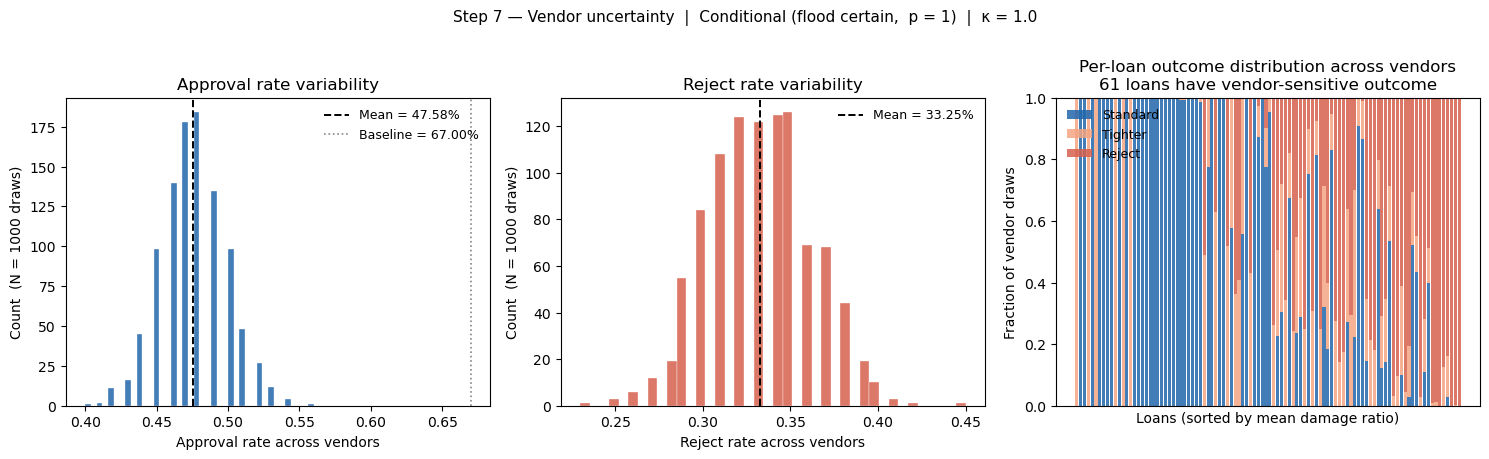

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

# 1. Distribution of approval rate across vendor draws
ax = axes[0]
ax.hist(approval_by_draw, bins=40, color=BLUE, alpha=0.85, edgecolor='white', linewidth=0.3)
ax.axvline(approval_by_draw.mean(), color='black', lw=1.4, ls='--',
           label=f'Mean = {approval_by_draw.mean():.2%}')
ax.axvline((outcome_base == 'standard').mean(), color=GREY, lw=1.2, ls=':',
           label=f'Baseline = {(outcome_base == "standard").mean():.2%}')
ax.set_xlabel('Approval rate across vendors')
ax.set_ylabel(f'Count  (N = {N_VENDOR_DRAWS} draws)')
ax.set_title('Approval rate variability')
ax.legend(frameon=False, fontsize=9)

# 2. Distribution of reject rate
ax = axes[1]
ax.hist(reject_by_draw, bins=40, color=RED, alpha=0.85, edgecolor='white', linewidth=0.3)
ax.axvline(reject_by_draw.mean(), color='black', lw=1.4, ls='--',
           label=f'Mean = {reject_by_draw.mean():.2%}')
ax.set_xlabel('Reject rate across vendors')
ax.set_ylabel(f'Count  (N = {N_VENDOR_DRAWS} draws)')
ax.set_title('Reject rate variability')
ax.legend(frameon=False, fontsize=9)

# 3. Per-loan outcome frequency stacked bar
ax = axes[2]
freq_std = is_standard_draws.mean(axis=0)[idx_mean]
freq_tgt = is_tighter_draws.mean(axis=0)[idx_mean]
freq_rej = is_reject_draws.mean(axis=0)[idx_mean]
xp = np.arange(n_props)
ax.bar(xp, freq_std, color=BLUE,  alpha=0.85, label='Standard')
ax.bar(xp, freq_tgt, bottom=freq_std,             color=AMBER, alpha=0.85, label='Tighter')
ax.bar(xp, freq_rej, bottom=freq_std + freq_tgt,  color=RED,   alpha=0.85, label='Reject')
ax.set_xlabel('Loans (sorted by mean damage ratio)')
ax.set_ylabel('Fraction of vendor draws')
ax.set_title(f'Per-loan outcome distribution across vendors\n'
             f'{vendor_sensitive.sum()} loans have vendor-sensitive outcome')
ax.set_xticks([])
ax.legend(frameon=False, fontsize=9)

fig.suptitle(f'Step 7 — Vendor uncertainty  |  {framing_label}  |  κ = {KAPPA}',
             fontsize=11, y=1.01)
plt.tight_layout()
plt.savefig('../../outputs/figures/decision2/07_vendor_uncertainty.png', dpi=300, bbox_inches='tight')
plt.show()

## Step 8 — Sensitivity Analysis

### 8a. Sensitivity to κ (damage passthrough)

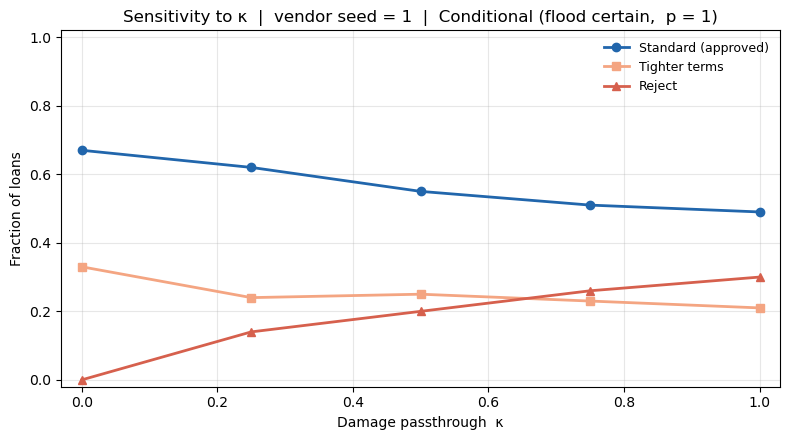

 kappa  approval  tighter  reject
 0.000     0.670    0.330   0.000
 0.250     0.620    0.240   0.140
 0.500     0.550    0.250   0.200
 0.750     0.510    0.230   0.260
 1.000     0.490    0.210   0.300


In [17]:
KAPPA_RANGE = [0.0, 0.25, 0.50, 0.75, 1.0]

rows_kappa = []
for k in KAPPA_RANGE:
    _d_eff_k = d_vendor if FRAMING == 'conditional' else (1.0 / RETURN_PERIOD) * d_vendor
    _v_str_k = np.maximum(v0 * (1.0 - k * _d_eff_k), 0.0)
    _ltv_k   = np.where(_v_str_k > 0, loan / _v_str_k, 9.99)
    rows_kappa.append({
        'kappa':    k,
        'approval': (_ltv_k <= LTV_THRESHOLD_1).mean(),
        'tighter':  ((_ltv_k > LTV_THRESHOLD_1) & (_ltv_k <= LTV_THRESHOLD_2)).mean(),
        'reject':   (_ltv_k > LTV_THRESHOLD_2).mean(),
    })
df_kappa = pd.DataFrame(rows_kappa)

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(df_kappa['kappa'], df_kappa['approval'], 'o-', color=BLUE,  lw=2, label='Standard (approved)')
ax.plot(df_kappa['kappa'], df_kappa['tighter'],  's-', color=AMBER, lw=2, label='Tighter terms')
ax.plot(df_kappa['kappa'], df_kappa['reject'],   '^-', color=RED,   lw=2, label='Reject')
ax.set_xlabel('Damage passthrough  κ')
ax.set_ylabel('Fraction of loans')
ax.set_title(f'Sensitivity to κ  |  vendor seed = {VENDOR_SEED}  |  {framing_label}')
ax.legend(frameon=False, fontsize=9)
ax.set_xlim(-0.03, 1.03)
ax.set_ylim(-0.02, 1.02)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../../outputs/figures/decision2/08a_sensitivity_kappa.png', dpi=300, bbox_inches='tight')
plt.show()

print(df_kappa.to_string(index=False, float_format='{:.3f}'.format))

### 8b. Sensitivity to LTV Thresholds

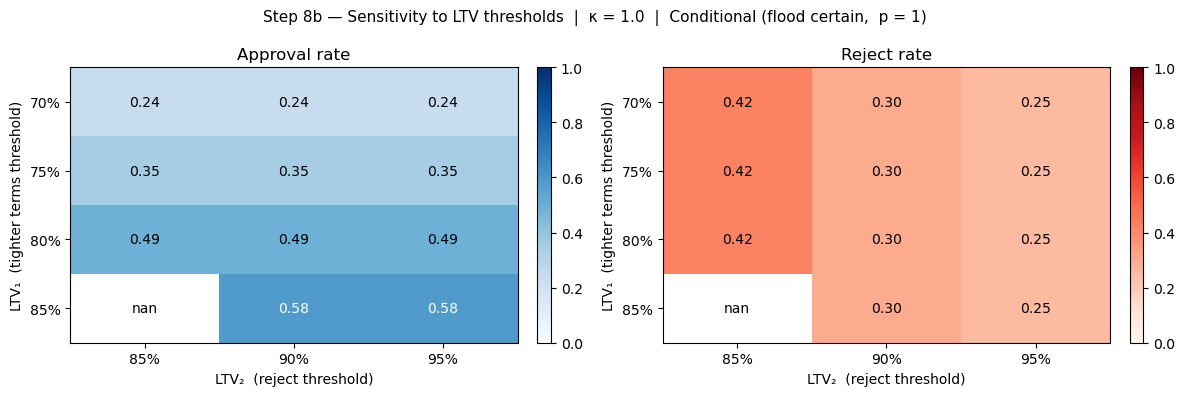

In [18]:
LTV1_RANGE = [0.70, 0.75, 0.80, 0.85]
LTV2_RANGE = [0.85, 0.90, 0.95]

# Compute stressed LTV once under current KAPPA
_d_eff_s = d_vendor if FRAMING == 'conditional' else (1.0 / RETURN_PERIOD) * d_vendor
_v_str_s = np.maximum(v0 * (1.0 - KAPPA * _d_eff_s), 0.0)
_ltv_s   = np.where(_v_str_s > 0, loan / _v_str_s, 9.99)

rows_thresh = []
for t1 in LTV1_RANGE:
    for t2 in LTV2_RANGE:
        if t2 <= t1:
            continue
        rows_thresh.append({
            'LTV1': t1, 'LTV2': t2,
            'approval': (_ltv_s <= t1).mean(),
            'tighter':  ((_ltv_s > t1) & (_ltv_s <= t2)).mean(),
            'reject':   (_ltv_s > t2).mean(),
        })
df_thresh = pd.DataFrame(rows_thresh)

# Heatmap: reject rate by threshold pair
import matplotlib.colors as mcolors
pivot_reject = df_thresh.pivot(index='LTV1', columns='LTV2', values='reject')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, col, title, cmap in [
    (axes[0], 'approval', 'Approval rate', 'Blues'),
    (axes[1], 'reject',   'Reject rate',   'Reds'),
]:
    piv = df_thresh.pivot(index='LTV1', columns='LTV2', values=col)
    im = ax.imshow(piv.values, aspect='auto', cmap=cmap, vmin=0, vmax=1)
    ax.set_xticks(range(len(piv.columns)))
    ax.set_yticks(range(len(piv.index)))
    ax.set_xticklabels([f'{v:.0%}' for v in piv.columns])
    ax.set_yticklabels([f'{v:.0%}' for v in piv.index])
    ax.set_xlabel('LTV₂  (reject threshold)')
    ax.set_ylabel('LTV₁  (tighter terms threshold)')
    ax.set_title(title)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    for i in range(len(piv.index)):
        for j in range(len(piv.columns)):
            ax.text(j, i, f'{piv.values[i, j]:.2f}', ha='center', va='center',
                    fontsize=10, color='white' if piv.values[i, j] > 0.5 else 'black')

fig.suptitle(f'Step 8b — Sensitivity to LTV thresholds  |  κ = {KAPPA}  |  {framing_label}',
             fontsize=11)
plt.tight_layout()
plt.savefig('../../outputs/figures/decision2/08b_sensitivity_thresholds.png', dpi=300, bbox_inches='tight')
plt.show()

## Step 9 — Pairwise Vendor Comparison

Two institutions hold identical portfolios but consult different vendors. How much do their underwriting decisions diverge?

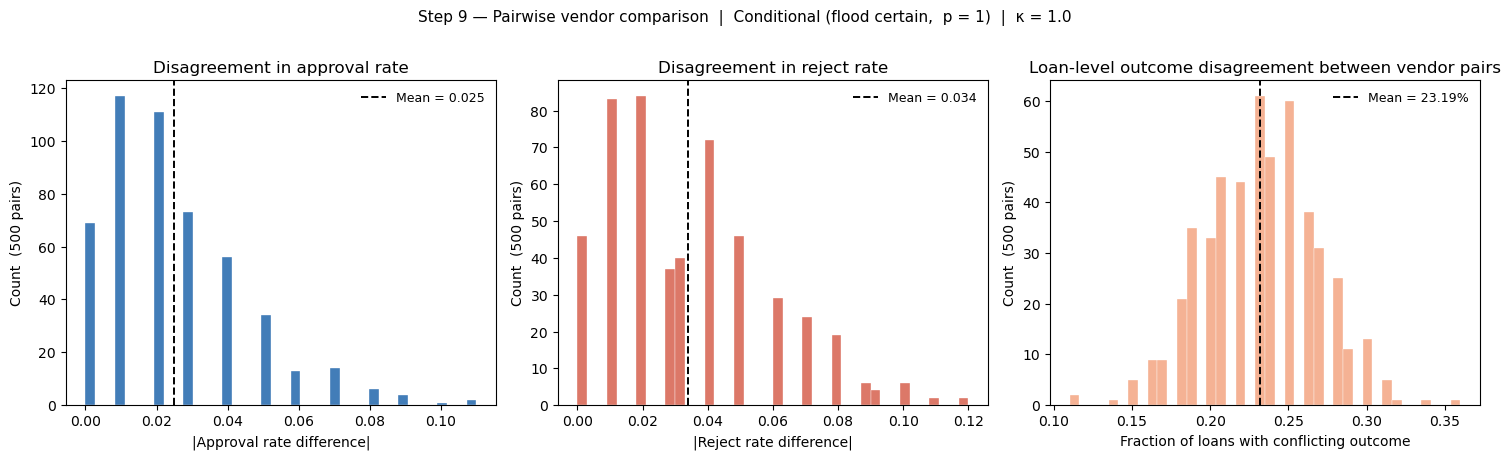

Pairwise disagreement summary:
  Approval rate diff:          mean = 0.025   max = 0.110
  Reject rate diff:            mean = 0.034   max = 0.120
  Loan-level outcome conflict: mean = 0.232   max = 0.360


In [19]:
N_PAIRS = 500
_rng_pairs = np.random.default_rng(77)
pi = _rng_pairs.integers(0, N_VENDOR_DRAWS, N_PAIRS)
pj = _rng_pairs.integers(0, N_VENDOR_DRAWS, N_PAIRS)
mask = pi != pj
pi, pj = pi[mask], pj[mask]

appr_i = is_standard_draws[pi].mean(axis=1)
appr_j = is_standard_draws[pj].mean(axis=1)
rej_i  = is_reject_draws[pi].mean(axis=1)
rej_j  = is_reject_draws[pj].mean(axis=1)

appr_diff = np.abs(appr_i - appr_j)
rej_diff  = np.abs(rej_i  - rej_j)

# Loan-level: fraction where the two vendors produce different outcomes
loan_disagree = (out_num_draws[pi] != out_num_draws[pj]).mean(axis=1)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

ax = axes[0]
ax.hist(appr_diff, bins=40, color=BLUE, alpha=0.85, edgecolor='white', linewidth=0.3)
ax.axvline(appr_diff.mean(), color='black', lw=1.4, ls='--',
           label=f'Mean = {appr_diff.mean():.3f}')
ax.set_xlabel('|Approval rate difference|')
ax.set_ylabel(f'Count  ({len(pi)} pairs)')
ax.set_title('Disagreement in approval rate')
ax.legend(frameon=False, fontsize=9)

ax = axes[1]
ax.hist(rej_diff, bins=40, color=RED, alpha=0.85, edgecolor='white', linewidth=0.3)
ax.axvline(rej_diff.mean(), color='black', lw=1.4, ls='--',
           label=f'Mean = {rej_diff.mean():.3f}')
ax.set_xlabel('|Reject rate difference|')
ax.set_ylabel(f'Count  ({len(pi)} pairs)')
ax.set_title('Disagreement in reject rate')
ax.legend(frameon=False, fontsize=9)

ax = axes[2]
ax.hist(loan_disagree, bins=40, color=AMBER, alpha=0.85, edgecolor='white', linewidth=0.3)
ax.axvline(loan_disagree.mean(), color='black', lw=1.4, ls='--',
           label=f'Mean = {loan_disagree.mean():.2%}')
ax.set_xlabel('Fraction of loans with conflicting outcome')
ax.set_ylabel(f'Count  ({len(pi)} pairs)')
ax.set_title('Loan-level outcome disagreement between vendor pairs')
ax.legend(frameon=False, fontsize=9)

fig.suptitle(f'Step 9 — Pairwise vendor comparison  |  {framing_label}  |  κ = {KAPPA}',
             fontsize=11, y=1.01)
plt.tight_layout()
plt.savefig('../../outputs/figures/decision2/09_pairwise_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"Pairwise disagreement summary:")
print(f"  Approval rate diff:          mean = {appr_diff.mean():.3f}   max = {appr_diff.max():.3f}")
print(f"  Reject rate diff:            mean = {rej_diff.mean():.3f}   max = {rej_diff.max():.3f}")
print(f"  Loan-level outcome conflict: mean = {loan_disagree.mean():.3f}   max = {loan_disagree.max():.3f}")